In [1]:
#importing libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#importing data

car=pd.read_csv("car.csv")

In [3]:
# data summary 
car.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [ ]:
#data info
car.info()

**DATA CLEANING AND PREPROCESSING**

 `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |

In [5]:
# mapping the driving_experience
experience_map = {
    "0-9y": 0,
    "10-19y": 1,
    "20-29y": 2,
    "30y+": 3
}
car["driving_experience"]=car["driving_experience"].map(experience_map)


 `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |

In [6]:
#mapping education
edu={
    "high school":1,
    "none":0,
    "university":2
}
car["education"]=car["education"].map(edu)


 `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |

In [7]:
# mapping income
inc={
    "upper class":3,
    "middle class":2,
    "poverty":0,
    "working class":1
    
}
car["income"]=car["income"].map(inc)


 `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |

In [8]:
#mapping vechile year
vc={
    "before 2015":0,
    "after 2015":1
}
car["vehicle_year"]=car["vehicle_year"].map(vc)


In [9]:
#replacing missing values with the mean
car["annual_mileage"]=car["annual_mileage"].fillna(car["annual_mileage"].mean())

 `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |

In [10]:
#mapping vihicle type
vt={
    "sedan":0,
    "sports car":1
}
car["vehicle_type"]=car["vehicle_type"].map(vt)


In [11]:
#replacing the missing values with the mean
car["credit_score"]=car["credit_score"].fillna(car["credit_score"].mean())

**DATASET OVERVIEW**

**the dataset contains the following**
- 10000 rows
- 18 features/columns
- no missing values
  
**target variable**
- is outcome
- 31.33% of the outcome claimed
  
**Categorical Balance**
driving_experience bins
- 35.30%  less than a year
- 32.99% 10 - 19 years
- 21.19% 20-29 years
- 10.52% 30+ years

  **Data Quality Checks**
  - no duplicates
  - age not negative
  - mileage not absurdly high
  

  

**EDA**

1 **Overall Claim Rate**

In [13]:
# Count claims vs. non-claims
claim_counts = car["outcome"].value_counts()
claim_rate = car["outcome"].mean() * 100

print("Claim counts:\n", claim_counts)
print(f"Overall claim rate: {claim_rate:.2f}%")


Claim counts:
 outcome
0.0    6867
1.0    3133
Name: count, dtype: int64
Overall claim rate: 31.33%


Out of 10,000 clients, 31.33% filed claims. This indicates that claims are relatively common ,nearly one in three clients and insurers must actively manage risk factors. The dataset shows moderate imbalance, which will influence both exploratory analysis and predictive modeling.

2 **Age & Driving Experience**

Do younger drivers and those with less driving experience file more claims?

In [22]:
car.groupby(["age","driving_experience"])["outcome"].mean()

age  driving_experience
0    0                     0.718254
1    0                     0.576867
     1                     0.268067
2    0                     0.491557
     1                     0.170358
     2                     0.052457
3    0                     0.379195
     1                     0.147590
     2                     0.045455
     3                     0.019011
Name: outcome, dtype: float64

Claim rates are highest among young drivers (16–25), reaching 72% for those with less than 10 years of experience. Inexperience is a strong risk factor across all age groups, but its impact diminishes with time. By 20–29 years of driving, claim rates fall below 10%. The safest segment is older drivers (65+) with 30+ years of experience, whose claim rate is just 1.9%. This confirms that youth and inexperience are major drivers of insurance risk.

3 **Financial Profile**

Does income or credit score affect claim likelihood?

In [15]:
#for the income

car.groupby("income")["outcome"].mean()

income
0    0.653804
1    0.453271
2    0.276894
3    0.133533
Name: outcome, dtype: float64

Claim rates decrease steadily as income increases. Poverty-level clients show the highest claim rate (65%), nearly five times greater than the wealthiest group (13%). This clear downward trend indicates that financial stress correlates with higher claim likelihood, while financial stability reduces risk. For insurers, this validates the use of income as a risk segmentation factor: lower-income clients may require higher premiums or stricter underwriting, while wealthier clients represent safer, more profitable policies

outcome
0.0    54.310241
1.0    45.599868
Name: credit_score, dtype: float64


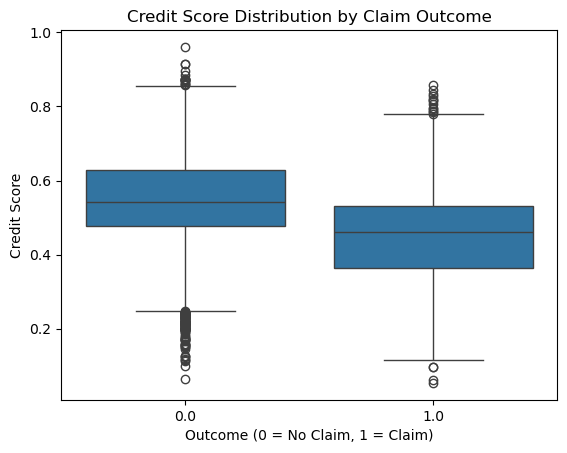

In [17]:

# Average credit score for claim vs. no-claim groups
credit_score_by_outcome = car.groupby("outcome")["credit_score"].mean()*100
print(credit_score_by_outcome)

sns.boxplot(x="outcome", y="credit_score", data=car)
plt.title("Credit Score Distribution by Claim Outcome")
plt.xlabel("Outcome (0 = No Claim, 1 = Claim)")
plt.ylabel("Credit Score")
plt.show()

Average credit scores are lower among claimants (45.7%) compared to non-claimants (54.3%). This suggests that financial responsibility, as measured by credit score, is associated with reduced claim likelihood. Insurers can leverage credit score as a risk indicator, with lower scores signaling higher risk and higher scores reflecting safer, more stable clients.

C:\Users\precious\AppData\Local\Temp\ipykernel_7752\617792087.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = car.groupby(["income", "credit_score_bin"])["outcome"].mean().unstack()


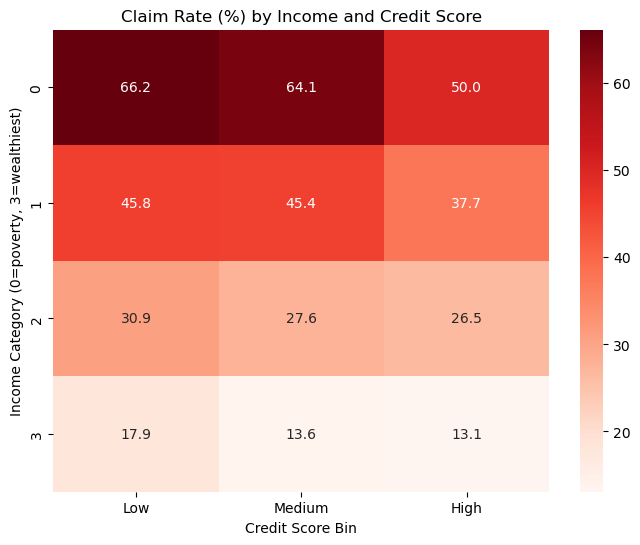

In [18]:

#credit score bins
bins = [0, 0.4, 0.6, 1.0]
labels = ["Low", "Medium", "High"]
car["credit_score_bin"] = pd.cut(car["credit_score"], bins=bins, labels=labels, right=False)

# Grouping by income and credit score bin
pivot_table = car.groupby(["income", "credit_score_bin"])["outcome"].mean().unstack()

# Plotting the  heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table * 100, annot=True, fmt=".1f", cmap="Reds")
plt.title("Claim Rate (%) by Income and Credit Score")
plt.xlabel("Credit Score Bin")
plt.ylabel("Income Category (0=poverty, 3=wealthiest)")
plt.show()

When combining income and credit score, poverty-level clients consistently show the highest claim rates, even when credit scores are high. Wealthier clients, especially those with high credit scores, show the lowest claim rates. This two-dimensional profile highlights that income is the dominant driver of risk, while credit score provides additional refinement. Insurers can leverage these combined indicators for precise segmentation: poverty-level clients with low credit scores represent the highest-risk group, while wealthy clients with high scores are the safest.

4 **Vehicle Information**

Do certain cars lead to more claims?

In [24]:
car.head(2)

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome,credit_score_bin
0,569520,3,0,0,1,3,0.629027,1.0,1,0.0,1.0,10238,12000.0,0,0,0,0,0.0,High
1,750365,0,1,0,0,0,0.357757,0.0,0,0.0,0.0,10238,16000.0,0,0,0,0,1.0,Low


In [26]:
# # Calculate the average claim rate (outcome) for each vehicle_year group
car.groupby("vehicle_year")["outcome"].mean()

vehicle_year
0    0.403330
1    0.106495
Name: outcome, dtype: float64

Claim rates are substantially higher for older vehicles (40%) compared to newer ones (11%). This suggests that modern safety features and improved reliability reduce claim likelihood. Insurers can use vehicle age as a key underwriting factor, charging higher premiums for older cars while rewarding newer vehicles with safer profiles.

In [29]:
#Vehicle Type 
car.groupby("vehicle_type")["outcome"].mean()

vehicle_type
0    0.312717
1    0.324948
Name: outcome, dtype: float64

Claim rates are slightly higher for sports cars (33%) compared to sedans (31%). Although the difference is modest in this dataset, sports cars are generally considered riskier due to driving behavior and repair costs. Insurers may apply higher premiums to sports cars

In [32]:
car.groupby("outcome")["annual_mileage"].mean()


outcome
0.0    11375.549735
1.0    12401.574221
Name: annual_mileage, dtype: float64

Claimants drive on average 1,000 km more per year than non-claimants (12,402 vs. 11,376). This confirms that higher mileage increases exposure and claim likelihood. Insurers can use mileage as a risk segmentation factor, charging higher premiums for high-mileage drivers while offering discounts to low-mileage clients.

C:\Users\precious\AppData\Local\Temp\ipykernel_7752\1267998724.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = car.groupby(["vehicle_type", "mileage_bin"])["outcome"].mean().unstack()


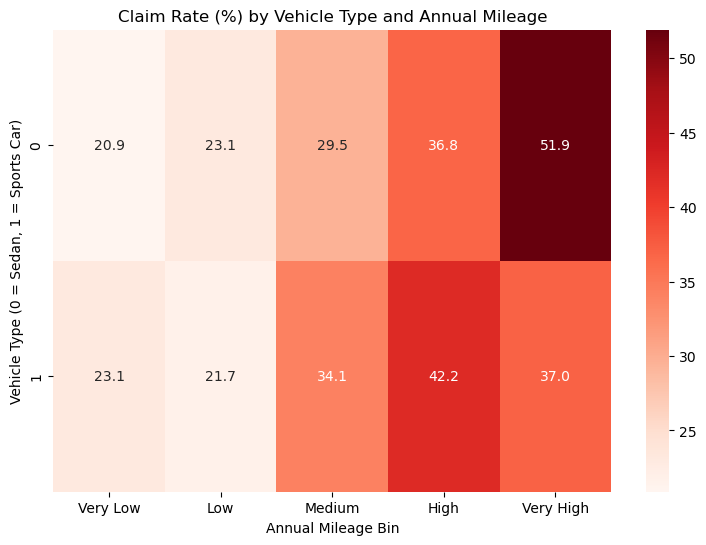

In [34]:
# Create mileage bins based on distribution
bins = [0, 8000, 11000, 13000, 16000, 22000]
labels = ["Very Low", "Low", "Medium", "High", "Very High"]
car["mileage_bin"] = pd.cut(car["annual_mileage"], bins=bins, labels=labels, right=False)

# Step 2: Group by vehicle_type and mileage_bin
pivot_table = car.groupby(["vehicle_type", "mileage_bin"])["outcome"].mean().unstack()

# Step 3: Plot heatmap
plt.figure(figsize=(9,6))
sns.heatmap(pivot_table * 100, annot=True, fmt=".1f", cmap="Reds")
plt.title("Claim Rate (%) by Vehicle Type and Annual Mileage")
plt.xlabel("Annual Mileage Bin")
plt.ylabel("Vehicle Type (0 = Sedan, 1 = Sports Car)")
plt.show()

Claim rates increase with annual mileage for both sedans and sports cars. Sports cars show higher risk at medium and high mileage, while sedans at very high mileage exceed 50% claim rates, making them the riskiest group overall. This confirms that mileage is a dominant risk factor, and insurers should incorporate mileage-based pricing while accounting for vehicle type interactions

In [36]:
car.head(2)

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome,credit_score_bin,mileage_bin
0,569520,3,0,0,1,3,0.629027,1.0,1,0.0,1.0,10238,12000.0,0,0,0,0,0.0,High,Medium
1,750365,0,1,0,0,0,0.357757,0.0,0,0.0,0.0,10238,16000.0,0,0,0,0,1.0,Low,Very High


5 **Risky Behaviors**

Do violations and past accidents predict claims?

Claim rate by number of DUIs:
 duis
0    0.358955
1    0.127891
2    0.066465
3    0.088235
4    0.300000
5    0.000000
6    0.000000
Name: outcome, dtype: float64


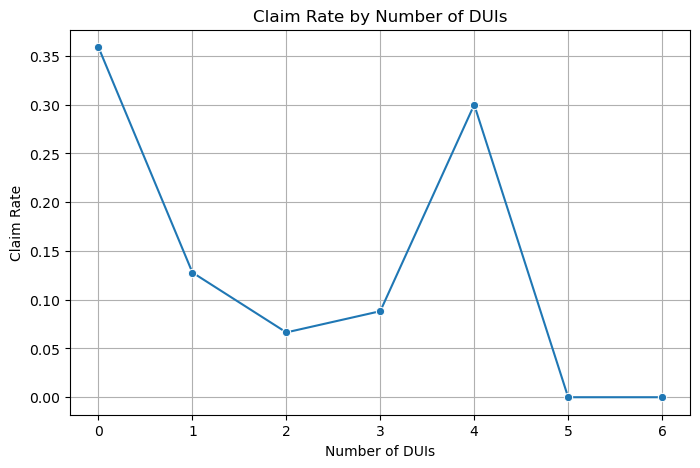

In [43]:

# Grouping by DUIs and calculate mean claim rate
dui_claim_rates = car.groupby("duis")["outcome"].mean()

print("Claim rate by number of DUIs:\n", dui_claim_rates)

# Plotting claim rate trend
plt.figure(figsize=(8,5))
sns.lineplot(x=dui_claim_rates.index, y=dui_claim_rates.values, marker="o")
plt.title("Claim Rate by Number of DUIs")
plt.xlabel("Number of DUIs")
plt.ylabel("Claim Rate")
plt.grid(True)
plt.show()

Clients with no DUIs show a 36% claim rate, while those with 1–3 DUIs surprisingly show lower rates (7–13%). At 4 DUIs, claim rates spike to 30%, confirming elevated risk among repeat offenders. However, very few clients have 5+ DUIs, making those results unreliable. Overall, DUI history remains a critical behavioral risk factor, but analysis should focus on presence vs. absence rather than exact counts


Claim rate by number of DUIs:
 past_accidents
0     0.469735
1     0.150308
2     0.129529
3     0.085139
4     0.073770
5     0.038793
6     0.041667
7     0.032787
8     0.000000
9     0.000000
10    0.000000
11    0.000000
12    0.000000
14    0.000000
15    0.000000
Name: outcome, dtype: float64


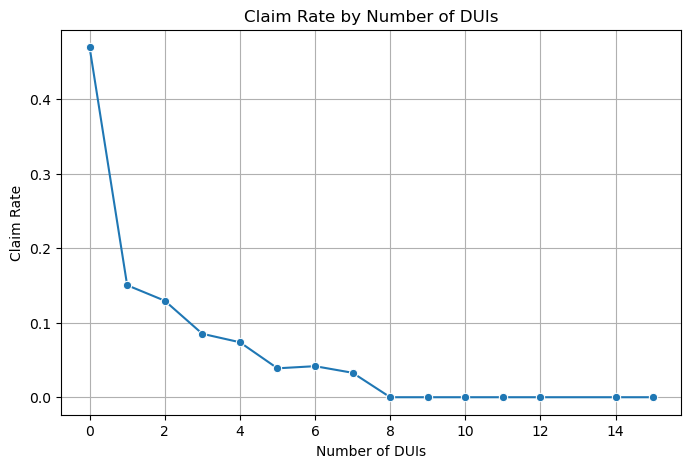

In [44]:
# Group by past_accidents and calculate mean claim rate
dui_claim_rates = car.groupby("past_accidents")["outcome"].mean()

print("Claim rate by number of past_accidents:\n", dui_claim_rates)

# Plot claim rate trend
plt.figure(figsize=(8,5))
sns.lineplot(x=dui_claim_rates.index, y=dui_claim_rates.values, marker="o")
plt.title("Claim Rate by Number of past_accidents")
plt.xlabel("Number of past_accidents")
plt.ylabel("Claim Rate")
plt.grid(True)
plt.show()

Claim rates are highest among clients with no recorded accidents (47%), while those with 1–4 accidents show much lower rates (7–15%). This counterintuitive pattern suggests possible data quality issues in accident reporting. Although accident history is typically a strong predictor of risk, insurers should validate the data before relying on it for underwriting decisions.

In [45]:
car.columns

Index(['id', 'age', 'gender', 'driving_experience', 'education', 'income',
       'credit_score', 'vehicle_ownership', 'vehicle_year', 'married',
       'children', 'postal_code', 'annual_mileage', 'vehicle_type',
       'speeding_violations', 'duis', 'past_accidents', 'outcome',
       'credit_score_bin', 'mileage_bin'],
      dtype='object')

In [49]:
car.drop(columns=["id","credit_score_bin","mileage_bin"],axis=1,inplace=True)

In [50]:
car.columns

Index(['age', 'gender', 'driving_experience', 'education', 'income',
       'credit_score', 'vehicle_ownership', 'vehicle_year', 'married',
       'children', 'postal_code', 'annual_mileage', 'vehicle_type',
       'speeding_violations', 'duis', 'past_accidents', 'outcome'],
      dtype='object')

In [52]:
car.to_csv("car_cleaned.csv")